Mounted at /content/drive
Fitting 3 folds for each of 16 candidates, totalling 48 fits


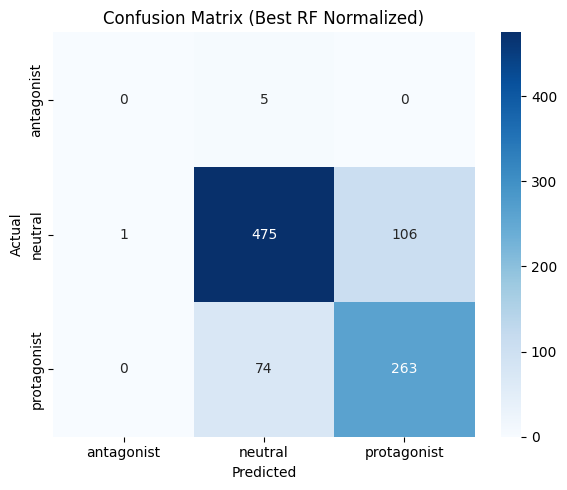


📊 Confusion Matrix:
             antagonist  neutral  protagonist
antagonist            0        5            0
neutral               1      475          106
protagonist           0       74          263

🏆 Best Random Forest (Normalized) Summary:
              precision    recall  f1-score     support
antagonist     0.000000  0.000000  0.000000    5.000000
neutral        0.857401  0.816151  0.836268  582.000000
protagonist    0.712737  0.780415  0.745042  337.000000
accuracy       0.798701  0.798701  0.798701    0.798701
macro avg      0.523379  0.532189  0.527103  924.000000
weighted avg   0.800000  0.798701  0.798471  924.000000

🔧 Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
📈 Precision: 0.5234
📈 Recall:    0.5322
📈 F1-score:  0.5271
🎯 Accuracy:  0.7987

📁 All results saved in: /content/drive/MyDrive/ML_CharacterType/random_forest_normalized


In [1]:
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# ==============================
# 0. Mount Google Drive (Colab)
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 1. Load normalized data
# ==============================
df = pd.read_csv("alias_sentence_features_primary_sorted_with_type.csv")
df['text'] = df['text'].fillna("")
df['is_primary_in_sentence'] = df['is_primary_in_sentence'].fillna(0)

# ==============================
# 2. Feature prep
# ==============================
X_num = df[['mention_count', 'word_count', 'is_primary_in_sentence']].astype(float)
tfidf = TfidfVectorizer(max_features=500)
X_text = tfidf.fit_transform(df['text'])

X = hstack([X_num, X_text])

# ==============================
# 3. Label encoding
# ==============================
le = LabelEncoder()
y = le.fit_transform(df['type'])

# ==============================
# 4. Train/test split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# ==============================
# 5. Grid search params
# ==============================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# ==============================
# 6. Run GridSearchCV
# ==============================
base_model = RandomForestClassifier(class_weight='balanced', random_state=42)
grid_search = GridSearchCV(
    base_model,
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# ==============================
# 7. Save root folder to Drive
# ==============================
root_dir = "/content/drive/MyDrive/ML_CharacterType/random_forest_normalized"
os.makedirs(root_dir, exist_ok=True)

# ==============================
# 8. Save all grid search results
# ==============================
cv_results = pd.DataFrame(grid_search.cv_results_)
param_results = cv_results[
    [
        'param_n_estimators',
        'param_max_depth',
        'param_min_samples_split',
        'param_min_samples_leaf',
        'mean_test_score'
    ]
]
param_results.to_csv(os.path.join(root_dir, "all_hyperparams_results.csv"), index=False)

# ==============================
# 9. Save each variation
# ==============================
for _, row in param_results.iterrows():
    max_depth_val = row['param_max_depth']
    max_depth_str = "NoneType" if pd.isna(max_depth_val) else str(max_depth_val)

    tag = (
        f"rf-n{row['param_n_estimators']}"
        f"-d{max_depth_str}"
        f"-s{row['param_min_samples_split']}"
        f"-l{row['param_min_samples_leaf']}"
    )

    model_dir = os.path.join(root_dir, tag)
    os.makedirs(model_dir, exist_ok=True)

    model = RandomForestClassifier(
        n_estimators=int(row['param_n_estimators']),
        max_depth=None if pd.isna(max_depth_val) else int(max_depth_val),
        min_samples_split=int(row['param_min_samples_split']),
        min_samples_leaf=int(row['param_min_samples_leaf']),
        class_weight='balanced',
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred_all = model.predict(X)
    temp_df = df.copy()
    temp_df['predicted_type'] = le.inverse_transform(y_pred_all)
    temp_df.to_csv(os.path.join(model_dir, "prediction.csv"), index=False)

    joblib.dump(model, os.path.join(model_dir, "model.pkl"))

# ==============================
# 10. Evaluate best model
# ==============================
y_pred_best = best_rf.predict(X_test)
report_dict = classification_report(
    y_test,
    y_pred_best,
    target_names=le.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()
acc = accuracy_score(y_test, y_pred_best)

# ==============================
# 11. Save best model results
# ==============================
report_df.to_csv(os.path.join(root_dir, "classification_report.csv"), index=True)

with open(os.path.join(root_dir, "best_params.txt"), "w") as f:
    f.write(str(grid_search.best_params_))

joblib.dump(best_rf, os.path.join(root_dir, "best_model.pkl"))
joblib.dump(le, os.path.join(root_dir, "label_encoder.pkl"))
joblib.dump(tfidf, os.path.join(root_dir, "tfidf.pkl"))

best_pred_df = df.copy()
best_pred_df['predicted_type'] = le.inverse_transform(best_rf.predict(X))
best_pred_df.to_csv(os.path.join(root_dir, "best_prediction.csv"), index=False)

# ==============================
# 12. Confusion matrix
# ==============================
cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Best RF Normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(root_dir, "confusion_matrix.png"))
plt.show()

# ==============================
# 13. Print summary
# ==============================
print("\n📊 Confusion Matrix:")
print(cm_df)

print("\n🏆 Best Random Forest (Normalized) Summary:")
print(report_df)
print(f"\n🔧 Best Parameters: {grid_search.best_params_}")
print(f"📈 Precision: {report_dict['macro avg']['precision']:.4f}")
print(f"📈 Recall:    {report_dict['macro avg']['recall']:.4f}")
print(f"📈 F1-score:  {report_dict['macro avg']['f1-score']:.4f}")
print(f"🎯 Accuracy:  {acc:.4f}")
print(f"\n📁 All results saved in: {root_dir}")

#MAJORITY VOTE


In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ========= CONFIG =========
IN_CSV  = "alias_sentence_features_primary_sorted.csv"             # data baru
OUT_CSV = "final_normalized.csv"  # hasil

# ========= LOAD ===========
df = pd.read_csv(IN_CSV)

# ========= COLUMNS =========
scale_cols = ["mention_count", "word_count"]      # hanya dua ini dinormalisasi
bool_col   = "is_primary_in_sentence"             # disimpan sebagai boolean

# -- pastikan tipe --
for col in scale_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# kolom boolean → True/False
df[bool_col] = df[bool_col].astype(bool)

# ========= MIN-MAX NORMALIZATION (0-1) =========
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# ========= SAVE =================================
df.to_csv(OUT_CSV, index=False)
print(f"✅  mention_count & word_count ternormalisasi; '{bool_col}' tetap boolean ➜ {OUT_CSV}")


✅  mention_count & word_count ternormalisasi; 'is_primary_in_sentence' tetap boolean ➜ final_normalized.csv


In [4]:
"""
label_final_normalized.py
-------------------------
• Memuat Random-Forest terbaik + artefak TF-IDF & LabelEncoder
• Memprediksi label `type` untuk `final_normalized.csv`
• Menambahkan kolom probabilitas dan menyimpan ke `final_labeled.csv`
"""

import os, joblib, pandas as pd
from scipy.sparse import hstack

# ═════ PATHS ════════════════════════════════════════════════════════
ROOT_DIR      = "/content/drive/MyDrive/ML_CharacterType/random_forest_normalized"              # folder model
BEST_MODEL    = os.path.join(ROOT_DIR, "best_model.pkl")
TFIDF_VEC     = os.path.join(ROOT_DIR, "tfidf.pkl")
LBL_ENCOD     = os.path.join(ROOT_DIR, "label_encoder.pkl")

DATA_IN       = "final_normalized.csv"     # sudah dinormalisasi
DATA_OUT      = "final_labeled.csv"        # hasil berlabel

# ═════ LOAD ARTEFAK MODEL ═══════════════════════════════════════════
rf    = joblib.load(BEST_MODEL)
tfidf = joblib.load(TFIDF_VEC)
le    = joblib.load(LBL_ENCOD)

# ═════ LOAD & PREPARE DATA BARU ═════════════════════════════════════
df = pd.read_csv(DATA_IN)

# pastikan kolom numerik dalam float (bool→float utk hstack)
num_cols = ["mention_count", "word_count", "is_primary_in_sentence"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(float)

X_num  = df[num_cols].values
X_text = tfidf.transform(df["text"].fillna(""))
X      = hstack([X_num, X_text])

# ═════ PREDICT  ═════════════════════════════════════════════════════
y_pred = rf.predict(X)
probs  = rf.predict_proba(X)

df["predicted_type"] = le.inverse_transform(y_pred)
for idx, cls in enumerate(le.classes_):
    df[f"conf_{cls}"] = probs[:, idx]

# ═════ SAVE  ════════════════════════════════════════════════════════
df.to_csv(DATA_OUT, index=False)
print(f"✅  File berlabel disimpan ➜ {DATA_OUT}")


✅  File berlabel disimpan ➜ final_labeled.csv


In [7]:
"""
label_final_normalized.py
-------------------------
• Muat Random-Forest terbaik + artefak TF-IDF & LabelEncoder
• Prediksi `predicted_type` untuk `final_normalized.csv`
• Tambah probabilitas & URUTKAN kolom sesuai permintaan
• Simpan ke `final_labeled_ordered.csv`
"""

import os, joblib, pandas as pd
from scipy.sparse import hstack

# ── PATHS ───────────────────────────────────────────────────────────
ROOT_DIR   = "/content/drive/MyDrive/ML_CharacterType/random_forest_normalized"
BEST_MODEL = os.path.join(ROOT_DIR, "best_model.pkl")
TFIDF_VEC  = os.path.join(ROOT_DIR, "tfidf.pkl")
LBL_ENCOD  = os.path.join(ROOT_DIR, "label_encoder.pkl")

DATA_IN    = "final_normalized.csv"
DATA_OUT   = "final_labeled_ordered.csv"

# ── LOAD ARTEFAK MODEL ─────────────────────────────────────────────
rf    = joblib.load(BEST_MODEL)
tfidf = joblib.load(TFIDF_VEC)
le    = joblib.load(LBL_ENCOD)

# ── LOAD & PREP DATA ───────────────────────────────────────────────
df = pd.read_csv(DATA_IN)

num_cols = ["mention_count", "word_count", "is_primary_in_sentence"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(float)

X_num  = df[num_cols].values
X_text = tfidf.transform(df["text"].fillna(""))
X      = hstack([X_num, X_text])

# ── PREDICT ────────────────────────────────────────────────────────
y_pred = rf.predict(X)
probs  = rf.predict_proba(X)

df["predicted_type"] = le.inverse_transform(y_pred)
for idx, cls in enumerate(le.classes_):
    df[f"conf_{cls}"] = probs[:, idx]

# ── RE-ORDER COLUMNS ───────────────────────────────────────────────
desired_order = [
    "story_id", "person", "aliases",
    "predicted_type",
    "sentence_id", "text", "mention_count", "word_count",
    "text_prev", "text_next", "bert_context",
    "is_primary_in_sentence",
    "conf_antagonist", "conf_neutral", "conf_protagonist"
]

missing = [c for c in desired_order if c not in df.columns]
if missing:
    raise ValueError(f"Kolom hilang di DataFrame: {missing}")

df = df[desired_order]

# ── SAVE ───────────────────────────────────────────────────────────
df.to_csv(DATA_OUT, index=False)
print(f"✅  File berlabel & terurut tersimpan ➜ {DATA_OUT}")


✅  File berlabel & terurut tersimpan ➜ final_labeled_ordered.csv


In [10]:
"""
majority_vote_custom_final.py   (no-fail version)
-------------------------------------------------
Output ➜ majority/final_predicted_majority_sorted_custom.csv
• ≥1 protagonist per story (hard guarantee)
• Antagonist bersyarat (confidence / mention)
• Sisanya others
"""

import os
import pandas as pd

# ── PATH & PARAMS ───────────────────────────────────────────────────
IN_CSV  = "final_labeled_ordered.csv"
OUT_CSV = "final_predicted_majority_sorted_custom.csv"

THR_ANT    = 0.50   # rata2 confidence antagonist
REL_THRESH = 0.20   # 20 % dari max mention_total

# ── LOAD ────────────────────────────────────────────────────────────
df = pd.read_csv(IN_CSV)

# ── 1. Statistik tokoh ─────────────────────────────────────────────
agg = (
    df.groupby(["story_id", "person"]).agg(
        pro_cnt        = ("predicted_type", lambda s: (s == "protagonist").sum()),
        ant_cnt        = ("predicted_type", lambda s: (s == "antagonist").sum()),
        oth_cnt        = ("predicted_type", lambda s: (s == "others").sum()),
        pro_conf_total = ("conf_protagonist", "sum"),
        ant_conf_total = ("conf_antagonist",  "sum"),
        mention_total  = ("mention_count",    "sum"),
    )
    .reset_index()
)

def majority(row):
    if row.pro_cnt == 0 and row.ant_cnt == 0:
        return "others"
    return max(
        {"protagonist": row.pro_cnt, "antagonist": row.ant_cnt, "others": row.oth_cnt},
        key=lambda k: {"protagonist": row.pro_cnt,
                       "antagonist" : row.ant_cnt,
                       "others"     : row.oth_cnt}[k],
    )

agg["label"] = agg.apply(majority, axis=1)

def choose(sub, sort_cols, asc):
    """Pick index of best candidate; sort_cols & asc list same len."""
    return sub.sort_values(sort_cols, ascending=asc).index[0]

# ── 2 – 4. Per-story logika utama ───────────────────────────────────
for sid, idx in agg.groupby("story_id").groups.items():
    sub = agg.loc[idx]

    # 2️⃣  Protagonist wajib (bukti kalimat / mention terbesar)
    if (sub.label == "protagonist").sum() == 0:
        pro_cand = sub[sub.pro_cnt > 0]
        cand = choose(pro_cand, ["pro_cnt", "pro_conf_total", "mention_total"], asc=[False]*3) \
               if not pro_cand.empty else choose(sub, ["mention_total"], asc=[False])
        agg.loc[cand, "label"] = "protagonist"

    # 3️⃣  Antagonist berbukti (kalimat)
    sub = agg.loc[idx]
    if (sub.label == "antagonist").sum() == 0:
        ant_cand = sub[sub.ant_cnt > 0]
        if not ant_cand.empty:
            cand = choose(ant_cand,
                          ["ant_cnt", "ant_conf_total", "mention_total"],
                          asc=[False]*3)
            agg.loc[cand, "label"] = "antagonist"

    # 4️⃣  Tambahan antagonist via confidence / mention
    sub = agg.loc[idx]
    if (sub.label == "antagonist").sum() == 0:
        others = sub[sub.label == "others"].copy()
        others["ant_conf_avg"] = others.ant_conf_total / others.oth_cnt.clip(lower=1)
        cand_conf = others[others.ant_conf_avg >= THR_ANT]
        if not cand_conf.empty:
            cand = choose(cand_conf,
                          ["ant_conf_avg", "ant_conf_total", "mention_total"],
                          asc=[False]*3)
            agg.loc[cand, "label"] = "antagonist"

    # 5️⃣  SANITY: jika masih tak ada protagonist → paksa mention tertinggi
    sub = agg.loc[idx]
    if (sub.label == "protagonist").sum() == 0:
        cand = choose(sub, ["mention_total"], asc=[False])
        agg.loc[cand, "label"] = "protagonist"

    # 6️⃣  Fallback antagonist via relatif mention_total
    sub = agg.loc[idx]
    if (sub.label == "antagonist").sum() == 0:
        max_m = sub.mention_total.max()
        cand_sub = sub[(sub.label == "others") &
                       (sub.mention_total >= REL_THRESH * max_m)]
        if not cand_sub.empty:
            cand = choose(cand_sub,
                          ["pro_conf_total", "mention_total"],
                          asc=[True, False])
            agg.loc[cand, "label"] = "antagonist"

# ── 5. Sort & save ─────────────────────────────────────────────────
agg["person_num"] = agg["person"].str.extract(r"Person-(\d+)", expand=False).astype(int)
final_df = (
    agg.sort_values(["story_id", "person_num"])
        .rename(columns={"label": "predicted_type"})
        .drop(columns="person_num")
        .reset_index(drop=True)
)

final_df.to_csv(OUT_CSV, index=False)
print("✅  Final file disimpan (tiap story ≥1 protagonist).")


✅  Final file disimpan (tiap story ≥1 protagonist).


In [11]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# =========================================================
# 1. LOAD FILE
# =========================================================
pred_path = "final_predicted_majority_sorted_custom.csv"
gt_path   = "Data Inggris - Data_Inggris_transformed.csv"

pred_df = pd.read_csv(pred_path)
gt_df   = pd.read_csv(gt_path)

# =========================================================
# 2. PILIH KOLOM YANG DIPERLUKAN
# =========================================================
pred_eval = pred_df[["story_id", "person", "predicted_type"]].copy()
gt_eval   = gt_df[["storyID", "characterID", "peran tokoh"]].copy()

# Samakan nama kolom
gt_eval = gt_eval.rename(columns={
    "storyID": "story_id",
    "characterID": "person",
    "peran tokoh": "true_type"
})

# =========================================================
# 3. RAPIAKAN LABEL
# =========================================================
pred_eval["predicted_type"] = pred_eval["predicted_type"].astype(str).str.strip().str.lower()
gt_eval["true_type"]        = gt_eval["true_type"].astype(str).str.strip().str.lower()

# Samakan label neutral menjadi others
gt_eval["true_type"] = gt_eval["true_type"].replace({
    "neutral": "others"
})

# Kalau ada variasi label lain, bisa ditambahkan di sini
pred_eval["predicted_type"] = pred_eval["predicted_type"].replace({
    "neutral": "others"
})

# =========================================================
# 4. MERGE PREDIKSI DENGAN GROUND TRUTH
# =========================================================
eval_df = pd.merge(
    gt_eval,
    pred_eval,
    on=["story_id", "person"],
    how="inner"
)

print("Jumlah data GT       :", len(gt_eval))
print("Jumlah data prediksi :", len(pred_eval))
print("Jumlah data match    :", len(eval_df))

# Cek jika ada data yang tidak match
if len(eval_df) != len(gt_eval):
    print("\nAda baris ground truth yang tidak berhasil dipasangkan ke prediksi.")
    missing_df = gt_eval.merge(pred_eval, on=["story_id", "person"], how="left", indicator=True)
    missing_df = missing_df[missing_df["_merge"] == "left_only"]
    print("\nContoh data GT yang tidak match:")
    print(missing_df.head())

# =========================================================
# 5. SIAPKAN LABEL
# =========================================================
labels = ["protagonist", "antagonist", "others"]

y_true = eval_df["true_type"]
y_pred = eval_df["predicted_type"]

# =========================================================
# 6. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"true_{x}" for x in labels], columns=[f"pred_{x}" for x in labels])

print("\n=== CONFUSION MATRIX ===")
print(cm_df)

# =========================================================
# 7. METRIK UMUM
# =========================================================
acc = accuracy_score(y_true, y_pred)

precision_macro = precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
recall_macro    = recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
f1_macro        = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
recall_weighted    = recall_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
f1_weighted        = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)

print("\n=== METRIK UMUM ===")
print(f"Accuracy            : {acc:.4f}")
print(f"Precision (macro)   : {precision_macro:.4f}")
print(f"Recall (macro)      : {recall_macro:.4f}")
print(f"F1-score (macro)    : {f1_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted)   : {recall_weighted:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")

# =========================================================
# 8. METRIK PER KELAS
# =========================================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

# =========================================================
# 9. SIMPAN HASIL
# =========================================================
cm_df.to_csv("confusion_matrix.csv", index=True)

report_dict = classification_report(
    y_true, y_pred, labels=labels, output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("classification_report.csv", index=True)

summary_df = pd.DataFrame([{
    "accuracy": acc,
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_weighted": f1_weighted
}])
summary_df.to_csv("evaluation_summary.csv", index=False)

print("\n✅ File evaluasi disimpan:")
print("- confusion_matrix.csv")
print("- classification_report.csv")
print("- evaluation_summary.csv")

Jumlah data GT       : 1542
Jumlah data prediksi : 1542
Jumlah data match    : 1542

=== CONFUSION MATRIX ===
                  pred_protagonist  pred_antagonist  pred_others
true_protagonist               176               10           12
true_antagonist                  0               11            5
true_others                     22              113         1193

=== METRIK UMUM ===
Accuracy            : 0.8949
Precision (macro)   : 0.6523
Recall (macro)      : 0.8249
F1-score (macro)    : 0.6586
Precision (weighted): 0.9641
Recall (weighted)   : 0.8949
F1-score (weighted) : 0.9253

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 protagonist       0.89      0.89      0.89       198
  antagonist       0.08      0.69      0.15        16
      others       0.99      0.90      0.94      1328

    accuracy                           0.89      1542
   macro avg       0.65      0.82      0.66      1542
weighted avg       0.96      0.89      0.93      